# Ablation: Qwen3-VL-2B Input Modes
Compare: Single-image | Multi-image | Video mode

Run `python ablation_input_modes.py` for CLI, or use cells below.

In [1]:
import sys
sys.argv = ['ablation_input_modes.py']
from ablation_input_modes import *
import torch

In [2]:
VIDEO_PATH = "UltrasoundCrawler_KeyCode_20260323_v2/output/20260520_162816_youtube/media/case_reasoning/8V649L5Q368.mp4"
frames, info = sample_frames(VIDEO_PATH, 8)


VIDEO: 8V649L5Q368 | 1137s | 24fps | 27257 frames
  Sampled 8 frames: [np.float64(56.81), np.float64(202.95), np.float64(349.14), np.float64(495.29), np.float64(641.47), np.float64(787.62), np.float64(933.81), np.float64(1079.99)]


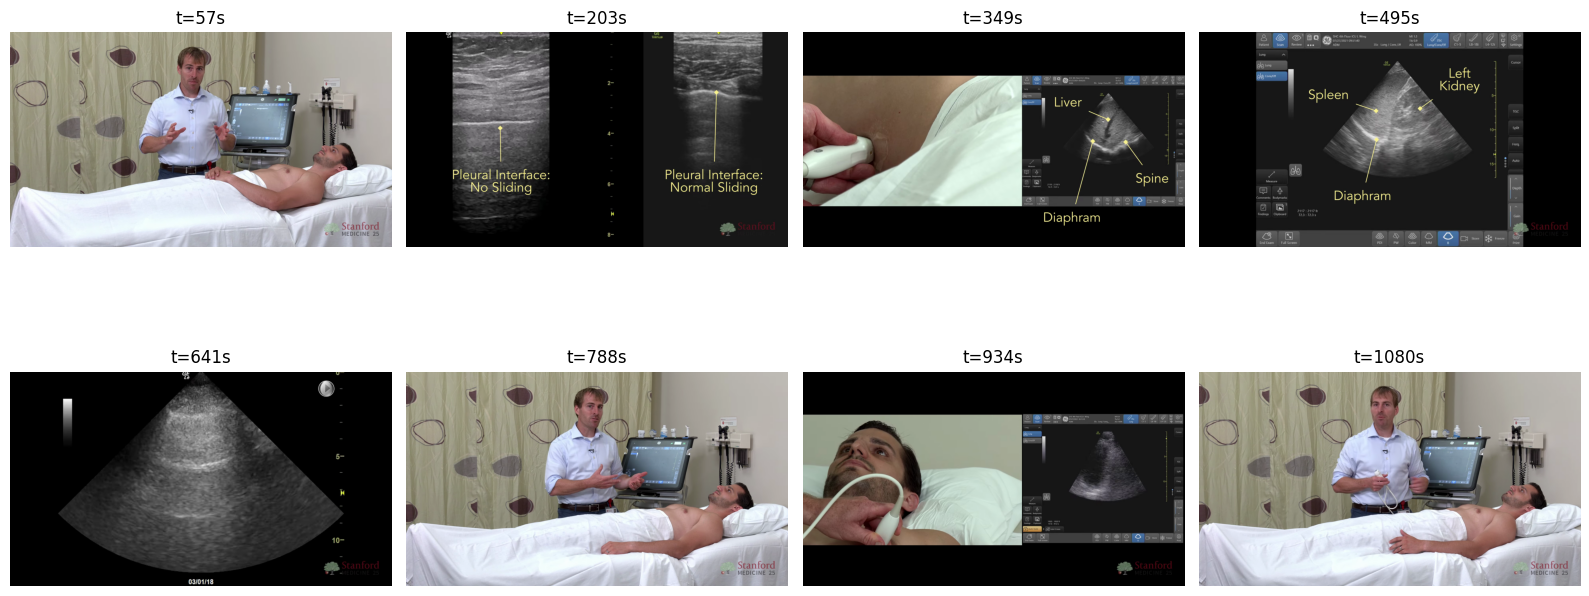

In [3]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, (ax, f) in enumerate(zip(axes.flat, frames)):
    ax.imshow(f['image']); ax.set_title(f"t={f['timestamp']:.0f}s"); ax.axis('off')
plt.tight_layout(); plt.show()

In [4]:
model, processor, device = load_model()

/Users/I761836/Desktop/Semester 3/live-ultrasound-video-understanding/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading Qwen/Qwen3-VL-2B-Instruct on mps...


Loading weights: 100%|██████████| 625/625 [00:00<00:00, 20726.94it/s]


Model loaded!


In [5]:
# Mode 1: Single image per call
m1 = run_mode1(model, processor, device, frames)


MODE 1: Single Image per Call (8 calls)
  [1/8] 26.9s | lecture_talking_head      | A doctor is speaking to the camera in a 
  [2/8] 22.8s | ppt_slide                 | Two ultrasound images showing the pleura
  [3/8] 23.6s | ultrasound                | Ultrasound image of the liver with label
  [4/8] 22.1s | ultrasound                | B-mode ultrasound image of the left kidn
  [5/8] 24.1s | ultrasound                | B-mode ultrasound of the liver showing a
  [6/8] 24.8s | lecture_talking_head      | A doctor is speaking to the camera in a 
  [7/8] 22.8s | ultrasound                | B-mode ultrasound of the lung, showing a
  [8/8] 23.2s | lecture_talking_head      | A doctor is speaking to the camera in a 

  TOTAL: 190.5s | Avg: 23.8s/frame | Tokens: 18424in+821out


In [6]:
# Mode 2: Multi-image one call
torch.mps.empty_cache()
m2 = run_mode2(model, processor, device, frames)


MODE 2: Multi-Image Video Classification (4 images, 1 call)
  NOTE: Limited to 4 to avoid OOM (original: 8)
  Time: 14.3s | Tokens: 1310in+164out
  Output (first 500): ```json
{
  "video_type": "mixed",
  "has_probe_technique": true,
  "has_instructor_face": true,
  "has_slides": true,
  "has_annotations_overlay": true,
  "anatomy_regions": [
    "pleural interface",
    "diaphragm",
    "liver",
    "spine",
    "spleen",
    "left kidney"
  ],
  "description": "A medical video featuring a doctor explaining a diagnostic ultrasound procedure. The video includes a live demonstration of ultrasound probe technique, a detailed ultrasound image with annotations, an
  Parsed: {
  "video_type": "mixed",
  "has_probe_technique": true,
  "has_instructor_face": true,
  "has_slides": true,
  "has_annotations_overlay": true,
  "anatomy_regions": [
    "pleural interface",
    "diaphragm",
    "liver",
    "spine",
    "spleen",
    "left kidney"
  ],
  "description": "A medical video featuring a 

In [7]:
torch.mps.empty_cache()

video_path = "UltrasoundCrawler_KeyCode_20260323_v2/output/20260520_162816_youtube/media/case_reasoning/8V649L5Q368.mp4"

m3 = run_mode3(model, processor, device, video_path, 8)


MODE 3: Video Mode (native, 1 call)


qwen-vl-utils using torchcodec to read video.
objc[68305]: Class AVFFrameReceiver is implemented in both /Users/I761836/Desktop/Semester 3/live-ultrasound-video-understanding/.venv/lib/python3.11/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x10c6ec3a8) and /opt/homebrew/Cellar/ffmpeg/8.1_1/lib/libavdevice.62.3.100.dylib (0x167868328). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[68305]: Class AVFAudioReceiver is implemented in both /Users/I761836/Desktop/Semester 3/live-ultrasound-video-understanding/.venv/lib/python3.11/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x10c6ec3f8) and /opt/homebrew/Cellar/ffmpeg/8.1_1/lib/libavdevice.62.3.100.dylib (0x167868378). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
[transformers] Asked to sample `fps` frames per second but no video metadata was provided which is required when sampling 

  Time: 6.6s | Tokens: 571in+108out
  Output: ```json
{
  "video_type": "mixed",
  "has_probe_technique": true,
  "has_instructor_face": true,
  "has_slides": false,
  "anatomy_regions": [],
  "description": "A medical professional is demonstrating ultrasound techniques while showing a live ultrasound image on a screen. The video includes both the instructor and the ultrasound display, with the instructor using a probe to capture images.",
  "training_value": "high",
  "recommendation": "keep"
}
```
  Parsed: {
  "video_type": "mixed",
  "has_probe_technique": true,
  "has_instructor_face": true,
  "has_slides": false,
  "anatomy_regions": [],
  "description": "A medical professional is demonstrating ultrasound techniques while showing a live ultrasound image on a screen. The video includes both the instructor and the ultrasound display, with the instructor using a probe to capture images.",
  "trainin


In [8]:
# Compare
print_comparison(m1, m2, m3)


COMPARISON
Metric                    Mode1(Single)      Mode2(Multi)       Mode3(Video)      
-------------------------------------------------------------------------------
Time (sec)                190.5              14.31              6.56              
API Calls                 8                  1                  1                 
Input Tokens              18424              1310               571               
Output Tokens             821                164                108               

--- Mode 1 per-frame ---
  t=56.81s: lecture_talking_head
  t=202.95s: ppt_slide
  t=349.14s: ultrasound
  t=495.29s: ultrasound
  t=641.47s: ultrasound
  t=787.62s: lecture_talking_head
  t=933.81s: ultrasound
  t=1079.99s: lecture_talking_head

--- Mode 2 ---
  {"video_type": "mixed", "has_probe_technique": true, "has_instructor_face": true, "has_slides": true, "has_annotations_overlay": true, "anatomy_regions": ["pleural interface", "diaphragm", "liver", "s

--- Mode 3 ---
  video_typ